# Поиск услуг на Авито: отбор 50 кандидатов

Задача. Пользователь ищет услугу коротким запросом, например "баня на дровах". Из корпуса в 189 тысяч объявлений
нужно отобрать 50 кандидатов так, чтобы среди них оказалось объявление, которое пользователь в итоге выбрал.

Метрика — Recall@50: доля "правильных" (выбранных пользователем) объявлений, которые попали в наши 50.
Порядок внутри пятидесяти не важен.

Часть 1. Загружаем данные, приводим их в порядок и смотрим, какие колонки полезны, а какие лишние.

## Как запустить

Структура папки:
```
dataset/                 train.parquet, benchmark_queries.parquet, benchmark_items.parquet
cache/                   дообученная нейросеть и эмбеддинги (cache.zip из раздела Releases репозитория)
solution.ipynb           этот ноутбук
requirements.txt         версии библиотек
```

1. Установить библиотеки: `pip install -r requirements.txt`.
2. Положить три parquet-файла в папку `dataset/` рядом с ноутбуком.
3. Выполнить все ячейки сверху вниз. Результат — файл `answer.csv` рядом с ноутбуком.

Два режима работы:
* с папкой `cache/` (скачать `cache.zip` из раздела Releases репозитория и распаковать рядом с ноутбуком): нейросеть не обучается заново, интернет не нужен, ноутбук воспроизводит
  отправленный `answer.csv`;
* без `cache/`: нейросеть скачивается с HuggingFace, дообучается, и корпус кодируется заново. Обучение нейросети
  на разном железе даёт немного разные веса, поэтому `answer.csv` может незначительно отличаться (качество то же).

Видеокарта используется автоматически, если она есть, — только для нейросети. Всё остальное (BM25, пулы кандидатов,
CatBoost) работает на CPU;

Время выполнения на CPU (AMD Ryzen 7 8845HS, 16 потоков, 32 ГБ RAM, по сути без видеокарты [она встроенная в проц, на 512мб VRAM]):

| Часть | Время |
|---|---|
| 1. Данные и EDA | 51 с |
| 2. Метрика и валидация | 40 с |
| 3. Нормализация слов | 7 с |
| 4. BM25 (9 индексов для сравнения) | 7 мин |
| 5. Бейзлайн: локация и фильтры | 2 мин |
| 6. Развилка | 0 с |
| 7. Источники кандидатов (нейросеть из cache/) | 3 мин |
| 8. Ранкер: пулы для 9 000 поисков и обучение | 10 мин |
| 9. Финальный ответ для тестовых запросов | 6 мин |
| Итого с папкой cache/ | 29 мин |
| Без cache/ дополнительно: дообучение нейросети и кодирование корпуса двумя моделями | ~50 мин на CPU, несколько минут на GPU |

Google Colab: включить GPU (среда выполнения → сменить среду выполнения → T4), загрузить папку проекта на google drive,
в ячейке ниже раскомментировать установку библиотек, подключение Drive и переход в папку проекта. В Colab всего 2 ядра
CPU, поэтому части, работающие на процессоре, выполняются в несколько раз медленнее, также нужно около 11 ГБ
оперативной памяти (в бесплатном Colab — около 12 ГБ).


In [1]:
# Только для Google Colab: установить недостающие библиотеки (на своём компьютере: pip install -r requirements.txt)
# !pip install catboost snowballstemmer pymorphy3 pymorphy3-dicts-ru sentence-transformers
# from google.colab import drive; drive.mount('/content/drive')   # подключить Google Drive
# %cd /content/drive/MyDrive/<папка_проекта>                      # перейти в папку проекта

## 1. Загрузка данных

In [2]:
import os, re, gc, time
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snowballstemmer

# единый стиль графиков
BLUE, ORANGE = '#2a78d6', '#eb6834'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': '#e1e0d9', 'axes.axisbelow': True, 'figure.dpi': 110})

T_START = time.time()
DATA = 'dataset'     # папка с тремя parquet-файлами (в Colab — путь на Google Drive, см. "Как запустить")
train = pd.read_parquet(f'{DATA}/train.parquet')
queries = pd.read_parquet(f'{DATA}/benchmark_queries.parquet')
items = pd.read_parquet(f'{DATA}/benchmark_items.parquet')

print('train  :', train.shape)
print('queries:', queries.shape)
print('items  :', items.shape)

train  : (497673, 19)
queries: (2452, 6)
items  : (189212, 14)


Что лежит в файлах:
* train — история поисков. Одна строка = "пользователь искал X и выбрал объявление Y".
  Колонки `search_*` описывают поиск, `item_*` — выбранное объявление.
* queries — 2 452 запроса, для которых нужно сделать предсказание (правильных ответов нет).
* items — корпус объявлений, среди которых мы ищем.

## 2. Приводим типы

Цена и координаты хранятся в parquet как `decimal` — с ним неудобно считать, переводим в обычные числа.
Пустые фильтры поиска бывают и `None`, и пустой строкой — приводим к одному виду (пустая строка).

In [3]:
for df in (train, items):
    for col in ['item_price', 'item_latitude', 'item_longitude']:
        df[col] = df[col].astype(float)

for df in (train, queries):
    df['search_infm_params_text'] = df['search_infm_params_text'].fillna('')

Одна строка train целиком (выведена "столбиком", чтобы было удобно читать): пользователь искал "автоподбор"
с фильтром по рейтингу и выбрал объявление "Автоподбор Разовый осмотр автомобиля".

In [4]:
train.iloc[1]

search_query                                                        автоподбор
search_location_id                                                      640860
search_is_delivery_search                                                    0
search_infm_params_text                   Рейтинг пользователя 4 звезды и выше
search_category                                                            114
item_title_raw                            Автоподбор Разовый осмотр автомобиля
item_rating_reviews_count                                                462.0
item_rating                                                           4.982684
item_price                                                              3500.0
item_microcat_id                                                       2303374
item_longitude                                                        44.05101
item_location_id                                                        640860
item_latitude                                       

## 3. Обзор колонок: что полезно, а что лишнее

Для каждой колонки считаем тип, долю пропусков, число уникальных значений и долю самого частого значения.
Если одно значение занимает почти 100% — колонка почти ничего не сообщает.

In [5]:
def column_report(df):
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append({
            'колонка': col,
            'пропуски, %': round(100 * s.isna().mean(), 1),
            'уникальных': s.nunique(),
            'самое частое значение, %': round(100 * s.value_counts(normalize=True, dropna=False).iloc[0], 2),
        })
    return pd.DataFrame(rows).set_index('колонка')

column_report(train)

,"пропуски, %",уникальных,"самое частое значение, %"
колонка,,,
search_query,0.0,74529,1.31
search_location_id,0.0,2782,7.29
search_is_delivery_search,0.0,2,100.00
search_infm_params_text,0.0,3724,32.95
search_category,0.0,4,99.99
item_title_raw,0.0,210029,0.64
item_rating_reviews_count,3.9,1372,4.13
item_rating,5.7,8832,48.09
item_price,0.0,2992,12.33


In [6]:
column_report(items)

,"пропуски, %",уникальных,"самое частое значение, %"
колонка,,,
item_title_raw,0.0,119952,0.46
item_rating_reviews_count,6.1,1170,6.14
item_rating,9.3,6007,49.89
item_price,0.0,2949,10.96
item_microcat_id,0.0,752,3.36
item_longitude,0.0,120004,0.70
item_location_id,0.0,2877,10.33
item_latitude,0.0,119778,0.70
item_is_phone_hidden,0.0,2,84.41


In [7]:
print('search_is_delivery_search в queries:', queries.search_is_delivery_search.value_counts().to_dict())
print('search_category в train  (доли):', train.search_category.value_counts(normalize=True).round(4).to_dict())
print('search_category в queries (доли):', queries.search_category.value_counts(normalize=True).round(4).to_dict())

search_is_delivery_search в queries: {0: 2452}
search_category в train  (доли): {114: 0.9999, 0: 0.0001, 81: 0.0, 10: 0.0}
search_category в queries (доли): {114: 0.9095, 0: 0.0905}


Что видно:
* `search_is_delivery_search` почти всегда 0 в train и всегда 0 в queries — колонка ничего не сообщает, удаляем.
* `search_category` в train почти всегда 114 ("Услуги"), но в queries 9% запросов с категорией 0 ("все категории").
  В train колонка бесполезна, но для запросов из queries она важна — оставляем.
* `item_rating` пустой примерно у 7–9% объявлений — у них ещё нет отзывов. Это не ошибка, а информация.
* `item_id` — идентификатор, как признак не нужен, но нужен для ответа.

Удаляем константную колонку:

In [8]:
train = train.drop(columns=['search_is_delivery_search'])
queries = queries.drop(columns=['search_is_delivery_search'])

Ещё две проверки: нет ли полных повторов в train и не странные ли значения цены.

In [9]:
SEARCH_KEY = ['search_query', 'search_location_id', 'search_infm_params_text', 'search_category']

print('повторов пары "поиск → объявление":', train.duplicated(SEARCH_KEY + ['item_id']).sum())
print('цена ≤ 1 ₽ (заглушка "договорная"), доля корпуса:', round((items.item_price <= 1).mean(), 3))

повторов пары "поиск → объявление": 30619
цена ≤ 1 ₽ (заглушка "договорная"), доля корпуса: 0.099


## 4. Собираем датасет "поиск → выбранные объявления"

Про повторы. ~31 тысяча строк (6%) — это одинаковый поиск и одинаковый выбор: например, разные люди в одном
городе искали "эвакуатор" и выбрали одно и то же объявление. Это не мусор, а сигнал популярности объявления,
поэтому из train их не удаляем.

Метрика считается по поискам, а не по строкам: один поиск может закончиться выбором нескольких объявлений.
Поэтому группируем train по параметрам поиска (текст, локация, фильтры, категория) и для каждого поиска собираем
множество выбранных объявлений — повторы при этом схлопываются.

In [10]:
searches = train.groupby(SEARCH_KEY)['item_id'].unique().rename('chosen_items').reset_index()
searches['n_chosen'] = searches.chosen_items.str.len()

print('поисков в train:', len(searches))
searches.n_chosen.value_counts(normalize=True).head(5).round(3).rename('доля поисков')

поисков в train: 354462


n_chosen
1    0.850
2    0.095
3    0.026
4    0.011
5    0.006
Name: доля поисков, dtype: float64

В 85% поисков выбрано ровно одно объявление. Значит, для каждого запроса нужно "поймать" 1–2 объявления
из десятков тысяч — задача очень узкая.

## 5. Слова в запросах

Приводим текст к простому виду: нижний регистр, `ё → е`, оставляем только буквы и цифры.

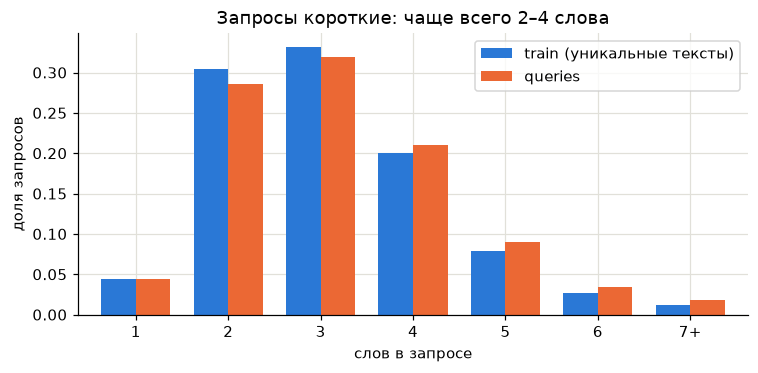

In [11]:
def words(text):
    return re.findall(r'[a-zа-я0-9]+', text.lower().replace('ё', 'е'))

train_texts = pd.Series(train.search_query.unique())       # уникальные тексты запросов из train
len_train = train_texts.map(lambda t: len(words(t))).clip(upper=7)
len_bench = queries.search_query.map(lambda t: len(words(t))).clip(upper=7)

share = pd.DataFrame({'train (уникальные тексты)': len_train.value_counts(normalize=True),
                      'queries': len_bench.value_counts(normalize=True)}).sort_index()
ax = share.plot.bar(color=[BLUE, ORANGE], width=0.75, figsize=(7, 3.5), rot=0)
ax.set_xticklabels([str(i) if i < 7 else '7+' for i in share.index])
ax.set_xlabel('слов в запросе'); ax.set_ylabel('доля запросов')
ax.set_title('Запросы короткие: чаще всего 2–4 слова')
plt.tight_layout(); plt.show()

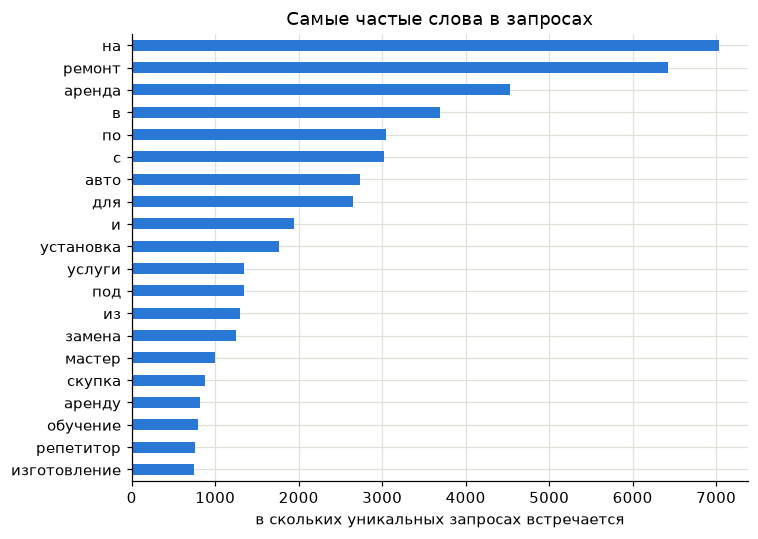

In [12]:
word_counts = pd.Series([w for t in train_texts for w in words(t)]).value_counts().head(20)

ax = word_counts.sort_values().plot.barh(color=BLUE, figsize=(7, 5))
ax.set_xlabel('в скольких уникальных запросах встречается')
ax.set_title('Самые частые слова в запросах')
plt.tight_layout(); plt.show()

Среди самых частых слов много предлогов ("в", "на", "для") — они есть почти везде и для поиска бесполезны.
Полезные слова — редкие и конкретные ("маникюр", "ремонт", "грузоперевозки"). Позже мы учтём это весом слова:
чем реже слово, тем важнее совпадение по нему.

Ещё заметно, что "аренда" и "аренду" посчитаны как разные слова. Чтобы разные формы одного слова совпадали,
дальше используем стемминг — отрезание окончаний.

## 6. Какие признаки полезны

В train есть только выбранные объявления. Чтобы понять, полезен ли признак, сравним:
* как часто условие выполняется для выбранного объявления;
* и как часто — для случайного объявления из корпуса при том же запросе.

Если у выбранных условие выполняется намного чаще — признак хорошо отличает "нужное" объявление от остальных.

Для сравнения слов используем стемминг (библиотека `snowballstemmer`): "баня", "бани" и "баню" превращаются в "бан".

In [13]:
stemmer = snowballstemmer.stemmer('russian')

@lru_cache(maxsize=None)
def stem(word):
    return stemmer.stemWord(word)

def stems(text):
    return {stem(w) for w in words(text)}

print(stems('Баня на дровах'), stems('Аренда бани с дровами'))

{'дров', 'бан', 'на'} {'дров', 'с', 'бан', 'аренд'}


Берём 30 000 случайных строк train и к каждой — случайное объявление из корпуса.

In [14]:
sample = train.sample(30_000, random_state=42).reset_index(drop=True)
rnd = items.sample(len(sample), replace=True, random_state=42).reset_index(drop=True)

# "Вид услуги" из фильтра поиска: текст после "Вид услуги " до "Тип услуги" или конца строки
def service_type(params):
    m = re.search(r'Вид услуги (.+?)(?: Тип услуги|$)', params)
    return m.group(1) if m else ''

sample_type = sample.search_infm_params_text.map(service_type)
has_type = sample_type != ''

In [15]:
def check(cand):
    '''Для каждой строки выборки: выполняется ли условие для объявления cand (выбранного или случайного).'''
    q_stems = sample.search_query.map(stems)
    title_stems = cand.item_title_raw.map(stems)
    text_stems = (cand.item_title_raw + ' ' + cand.item_description_raw.fillna('')).map(stems)
    same_type = [('Вид услуги ' + t) in (p or '') for t, p in zip(sample_type, cand.item_infm_params_text)]
    return pd.Series({
        'та же локация, что и поиск': (cand.item_location_id.values == sample.search_location_id.values).mean(),
        '"Вид услуги" совпадает с фильтром*': np.mean(np.array(same_type)[has_type.values]),
        'есть общее слово с заголовком': np.mean([len(a & b) > 0 for a, b in zip(q_stems, title_stems)]),
        'есть общее слово с заголовком или описанием': np.mean([len(a & b) > 0 for a, b in zip(q_stems, text_stems)]),
        'есть хотя бы 10 отзывов': (cand.item_rating_reviews_count.fillna(0) >= 10).mean(),
        'телефон скрыт': cand.item_is_phone_hidden.mean(),
        'сообщения запрещены': cand.item_is_message_forbidden.mean(),
    })

usefulness = pd.DataFrame({'выбранные, %': 100 * check(sample), 'случайные, %': 100 * check(rnd)})
usefulness['во сколько раз чаще'] = usefulness['выбранные, %'] / usefulness['случайные, %']
usefulness.round(1)

,"выбранные, %","случайные, %",во сколько раз чаще
"та же локация, что и поиск",82.8,1.7,49.6
"""Вид услуги"" совпадает с фильтром*",98.5,7.1,14.0
есть общее слово с заголовком,83.3,3.7,22.3
есть общее слово с заголовком или описанием,95.5,19.8,4.8
есть хотя бы 10 отзывов,69.1,59.5,1.2
телефон скрыт,12.0,15.8,0.8
сообщения запрещены,2.1,2.6,0.8


\* только для поисков, где пользователь выставил фильтр "Вид услуги".

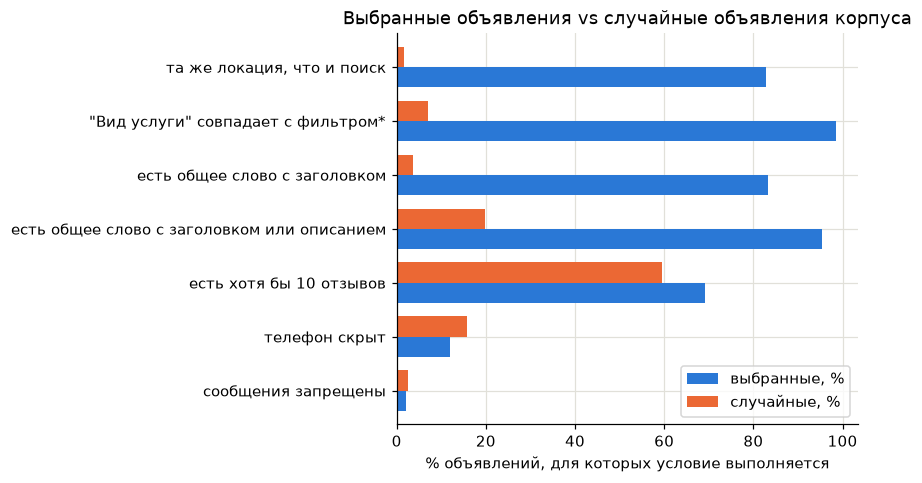

In [16]:
ax = usefulness[['выбранные, %', 'случайные, %']].iloc[::-1].plot.barh(color=[BLUE, ORANGE], width=0.75, figsize=(8, 4.5))
ax.set_xlabel('% объявлений, для которых условие выполняется')
ax.set_title('Выбранные объявления vs случайные объявления корпуса')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

Наконец, посмотрим, насколько хорошо слова запроса покрываются заголовком выбранного объявления:

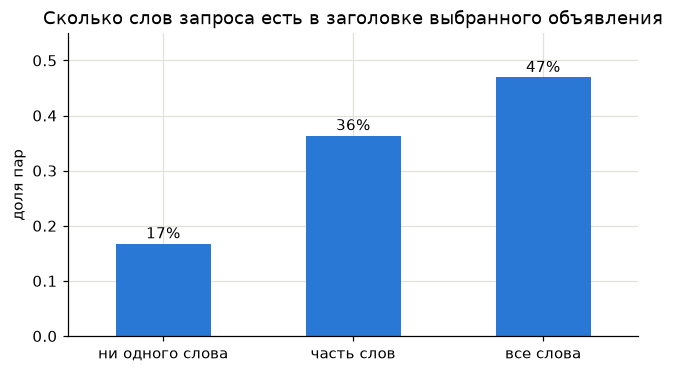

In [17]:
q_stems = sample.search_query.map(stems)
t_stems = sample.item_title_raw.map(stems)
covered = pd.Series([len(a & b) / len(a) if a else 0 for a, b in zip(q_stems, t_stems)])
groups = pd.cut(covered, [-0.01, 0, 0.99, 1], labels=['ни одного слова', 'часть слов', 'все слова'])

shares = groups.value_counts(normalize=True).reindex(['ни одного слова', 'часть слов', 'все слова'])
ax = shares.plot.bar(color=BLUE, rot=0, figsize=(6, 3.5))
for i, v in enumerate(shares.values):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center')
ax.set_ylabel('доля пар'); ax.set_ylim(0, shares.max() + 0.08)
ax.set_title('Сколько слов запроса есть в заголовке выбранного объявления')
plt.tight_layout(); plt.show()

## Выводы части 1

Лишнее: `search_is_delivery_search` — константа, удалили.

Самые полезные сигналы (см. таблицу выше):
1. Локация. Выбранное объявление в той же локации, что и поиск, в 83% случаев, случайное — в 2% (в ~50 раз реже).
   Это самый сильный фильтр.
2. "Вид услуги" из фильтра поиска. Если пользователь его выставил, выбранное объявление соответствует ему
   в 98.5% случаев, случайное — в 7%.
3. Общие слова запроса и объявления. Выбранное объявление обычно делит слова с запросом, случайное — почти никогда.
   Но у ~17% пар (каждой шестой) в заголовке нет ни одного слова запроса. Если добавить описание объявления, таких
   остаётся ~5% — эти случаи можно поймать только по смыслу (синонимы, перефразы).

Слабые сигналы: отзывы немного помогают (выбирают объявления с отзывами чуть чаще), а "телефон скрыт" и
"сообщения запрещены" почти не отличают выбранные объявления от случайных.

Следующий шаг (часть 2): научимся измерять качество — метрика Recall@50 и проверка на отложенных поисках из train.

# Часть 2. Как измеряем качество

Чтобы сравнивать разные способы поиска, нужна одна понятная цифра. У тестовых запросов (queries) правильных ответов
нет: их знает только платформа, а попыток отправки всего 7. Поэтому качество будем проверять на истории из train,
где ответы известны.

## 7. Метрика Recall@50

Для одного запроса считаем долю правильных объявлений, которые попали в наши 50 кандидатов. Итог — среднее по всем
запросам. Порядок внутри пятидесяти не важен.

In [18]:
def recall_at_k(predicted, correct, k=50):
    """predicted — {запрос: список кандидатов}, correct — {запрос: множество правильных объявлений}"""
    scores = []
    for query, right in correct.items():
        found = set(predicted.get(query, [])[:k]) & right
        scores.append(len(found) / len(right))
    return float(np.mean(scores))

# пример из условия: у запроса А нашли 1 из 1, у Б — 1 из 2, у В — 0 из 1
correct_example = {'А': {'a1'}, 'Б': {'b1', 'b2'}, 'В': {'c1'}}
predicted_example = {'А': ['a1', 'x1'], 'Б': ['b1', 'x2'], 'В': ['x3']}
recall_at_k(predicted_example, correct_example)       # (1 + 0.5 + 0) / 3 = 0.5

0.5

## 8. Валидация: откладываем часть поисков из train

Идея: берём часть поисков из train, "забываем", что выбрал пользователь, ищем для них кандидатов и сравниваем
с настоящим выбором. Чтобы такая проверка была похожа на тестовые запросы, соблюдаем три правила.

1. Один поиск на один уникальный текст запроса — в queries все тексты разные.
2. Отложенные поиски удаляем из train. Всё, чему мы дальше учимся (статистика по локациям, обучение нейросети
   и ранкера), берётся только из оставшейся части — назовём её `fit`. Иначе мы подсмотрим ответы.
3. Ищем в корпусе бенчмарка, добавив в него правильные объявления отложенных поисков. Большинства объявлений
   из train в корпусе бенчмарка нет, а искать нужно среди тех же "соседей", что и у тестовых запросов.

Откладываем 9 000 текстов: 3 000 — для проверки качества (`val`), 6 000 — для обучения ранкера (`rank`),
он появится в части про второй этап.

In [19]:
def make_split(train, n_val=3000, n_rank=6000, seed=42):
    rng = np.random.RandomState(seed)
    chosen_texts = rng.choice(train.search_query.unique(), n_val + n_rank, replace=False)

    # все поиски с выбранными текстами -> по одному случайному поиску на текст
    holdout = train[train.search_query.isin(chosen_texts)][SEARCH_KEY].drop_duplicates()
    holdout = holdout.sample(frac=1, random_state=seed).drop_duplicates('search_query')
    # перемешиваем ещё раз, уже по текстам, и делим на val / rank
    holdout = holdout.sort_values('search_query').sample(frac=1, random_state=seed + 1).reset_index(drop=True)
    holdout['query_id'] = ['h%06d' % i for i in range(len(holdout))]
    holdout['part'] = np.where(np.arange(len(holdout)) < n_val, 'val', 'rank')

    # строки train отложенных поисков и всё остальное (fit)
    holdout_rows = train.merge(holdout, on=SEARCH_KEY)
    is_holdout = train.merge(holdout[SEARCH_KEY].assign(h=1), on=SEARCH_KEY, how='left')['h'].eq(1).values
    fit = train[~is_holdout].reset_index(drop=True)
    return fit, holdout, holdout_rows

fit, holdout, holdout_rows = make_split(train)
correct = holdout_rows.groupby('query_id')['item_id'].apply(set).to_dict()   # правильные ответы отложенных поисков
val = holdout[holdout.part == 'val'].reset_index(drop=True)
correct_val = {q: correct[q] for q in val.query_id}

print('fit (для обучения):', len(fit), 'строк')
print('отложено поисков: val =', (holdout.part == 'val').sum(), ', rank =', (holdout.part == 'rank').sum())

fit (для обучения): 487634 строк
отложено поисков: val = 3000 , rank = 6000


Зачем перемешивать дважды. Популярный текст ("маникюр") встречается во многих поисках. Если перемешать поиски
и взять первые 3 000, популярные тексты чаще оказываются в начале, и валидация перекашивается в их сторону.
В первой версии решения так и было: 66% валидационных текстов встречались в train против 37% у тестовых запросов.
Второе перемешивание по уникальным текстам это исправляет.

Теперь собираем корпус для валидации:

In [20]:
ITEM_COLS = list(items.columns)
extra = holdout_rows[~holdout_rows.item_id.isin(set(items.item_id))].drop_duplicates('item_id')[ITEM_COLS ]
corpus_val = pd.concat([items, extra], ignore_index=True)   # первые 189 212 строк — корпус бенчмарка

print('корпус бенчмарка:', len(items))
print('добавлено правильных объявлений:', len(extra))
print('корпус для валидации:', len(corpus_val))

корпус бенчмарка: 189212
добавлено правильных объявлений: 8735
корпус для валидации: 197947


Дальше из `train` и `fit` нужны только колонки для статистики. Удаляем тексты описаний и параметров — это экономит около 4 ГБ памяти (важно для Google Colab, где её ~12 ГБ).

In [21]:
STAT_COLS = ['search_query', 'search_location_id', 'search_infm_params_text', 'search_category', 'item_id',
             'item_title_raw', 'item_location_id', 'item_latitude', 'item_longitude', 'item_microcat_id']
train, fit = train[STAT_COLS], fit[STAT_COLS]
gc.collect();

## 9. Похожа ли валидация на тестовые запросы

In [22]:
def describe_searches(s, known_texts):
    return pd.Series({
        'текст запроса уже встречался в обучающих данных': s.search_query.isin(known_texts).mean(),
        'слов в запросе (среднее)': s.search_query.map(lambda t: len(words(t))).mean(),
        'есть фильтр "Вид услуги"': (s.search_infm_params_text.map(service_type) != '').mean(),
        'поиск без категории': (s.search_category == 0).mean(),
    })

pd.DataFrame({'валидация': describe_searches(val, set(fit.search_query)),
              'тестовые запросы': describe_searches(queries, set(train.search_query))}).round(3)

,валидация,тестовые запросы
текст запроса уже встречался в обучающих данных,0.375,0.370
слов в запросе (среднее),3.084,3.203
"есть фильтр ""Вид услуги""",0.481,0.340
поиск без категории,0.000,0.091


По доле знакомых текстов и длине запросов валидация совпадает с тестовыми запросами. Есть и отличия:
в тестовых запросах реже стоит фильтр "Вид услуги" и встречаются поиски без категории, которых в train почти нет.
Учтём это при построении решения. Ещё одно, более важное отличие обнаружится ближе к концу, когда сравним
результаты на валидации с лидербордом.

Проверим, что всё работает: ответ из 50 случайных объявлений.

In [23]:
rng = np.random.default_rng(42)
all_ids = corpus_val.item_id.values
random_answer = {q: list(rng.choice(all_ids, 50, replace=False)) for q in val.query_id}
print('Recall@50 случайного ответа:', round(recall_at_k(random_answer, correct_val), 5))

Recall@50 случайного ответа: 0.00017


Случайные 50 объявлений из ~200 тысяч находят правильное примерно в 0.02% случаев: без подсказок задача безнадёжна.

Итог части 2: есть метрика и честная проверка на 3 000 отложенных поисков. В следующей части начнём с поиска
по словам: сначала приведём слова к общему виду (стемминг и лемматизация), затем — алгоритм BM25.

# Часть 3. Приводим слова к общему виду

Поиск по словам сравнивает слова запроса и объявления. Но в русском у одного слова много форм: пользователь пишет
"баню на дровах", а в объявлении "Баня на дровах". Если сравнивать слова как есть, "баню" и "баня" не совпадут.

Есть два стандартных способа привести формы к одной:
* стемминг — по правилам отрезаем окончание и часть суффиксов: "баню" → "бан". Словаря нет, поэтому быстро,
  но грубо: иногда режет лишнее или не склеивает формы;
* лемматизация — по словарю находим начальную форму: "баню" → "баня". Точнее, но медленнее.

Для стемминга используем `snowballstemmer` (уже был в части 1), для лемматизации — `pymorphy3`.

In [24]:
import time
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=None)
def lemma(word):
    return morph.parse(word)[0].normal_form.replace('ё', 'е')

def normalize(text, method):
    """method: 'none' — только нижний регистр и ё→е, 'stem' — стемминг, 'lemma' — лемматизация"""
    ws = words(text)
    if method == 'stem':
        return [stem(w) for w in ws]
    if method == 'lemma':
        return [lemma(w) for w in ws]
    return ws

## 10. Как это выглядит на словах

In [25]:
examples = ['баня', 'бани', 'баню', 'окно', 'окон', 'шью', 'шить', 'шила', 'стрижка', 'стрижки',
            'детей', 'ребенок', 'ремонт', 'ремонтный', 'грузоперевозки', 'iphone']
pd.DataFrame({'стемминг': [stem(w) for w in examples],
              'лемматизация': [lemma(w) for w in examples]}, index=pd.Index(examples, name='слово'))

,стемминг,лемматизация
слово,,
баня,бан,баня
бани,бан,баня
баню,бан,баня
окно,окн,окно
окон,окон,окно
шью,шью,шить
шить,шит,шить
шила,шил,шить
стрижка,стрижк,стрижка


Что видно:
* обе техники склеивают простые формы: "баня", "бани", "баню";
* стемминг ошибается на чередованиях и нерегулярных формах: "окно" и "окон" дают разные основы ("окн" и "окон"),
  как и "шью", "шить", "шила"; "детей" он не свяжет с "ребенок";
* лемматизация справляется со всеми этими случаями, потому что знает слова по словарю;
* обе не склеивают разные части речи: "ремонт" и "ремонтный" остаются разными словами. Такие связи позже будут
  ловить эмбеддинги — поиск по смыслу, а не по форме слова.

## 11. Сколько форм склеивается и сколько это стоит по времени

Возьмём все уникальные слова из запросов train и посмотрим, во сколько разных "нормальных форм" они превращаются.
Время меряем без кэша — как если бы обрабатывали каждое слово впервые.

In [26]:
vocab = sorted({w for t in train_texts for w in words(t)})

start = time.time(); stems_ = {stemmer.stemWord(w) for w in vocab}; t_stem = time.time() - start
start = time.time(); lemmas_ = {morph.parse(w)[0].normal_form for w in vocab}; t_lemma = time.time() - start

pd.DataFrame({'уникальных форм': [len(vocab), len(stems_), len(lemmas_)],
              'время на весь словарь, с': [0, round(t_stem, 2), round(t_lemma, 2)]},
             index=['без нормализации', 'стемминг', 'лемматизация'])

,уникальных форм,"время на весь словарь, с"
без нормализации,25894,0.00
стемминг,16281,0.78
лемматизация,16620,2.18


Обе техники сокращают словарь запросов примерно на треть (с 26 до 16 тысяч форм): разные формы одного слова
склеиваются. Лемматизация примерно в 3 раза медленнее стемминга, но для нас это неважно: каждое уникальное слово
обрабатывается один раз и запоминается (кэш), так что весь корпус нормализуется за секунды в обоих случаях.

## 12. Помогает ли нормализация находить нужное объявление

Вернёмся к проверке из части 1: есть ли общее слово у запроса и заголовка объявления. Сравним три способа
на тех же 30 000 парах: для выбранного объявления хотим совпадений побольше, для случайного — поменьше.

In [27]:
def overlap_stats(method):
    q = sample.search_query.map(lambda t: set(normalize(t, method)))
    chosen = sample.item_title_raw.map(lambda t: set(normalize(t, method)))
    random_ = rnd.item_title_raw.map(lambda t: set(normalize(t, method)))
    return pd.Series({
        'выбранные: есть общее слово, %': 100 * np.mean([len(a & b) > 0 for a, b in zip(q, chosen)]),
        'выбранные: все слова запроса в заголовке, %': 100 * np.mean([a <= b for a, b in zip(q, chosen) if a]),
        'случайные: есть общее слово, %': 100 * np.mean([len(a & b) > 0 for a, b in zip(q, random_)]),
    })

norm_table = pd.DataFrame({name: overlap_stats(m) for name, m in
                           [('без нормализации', 'none'), ('стемминг', 'stem'), ('лемматизация', 'lemma')]}).T
norm_table.round(1)

,"выбранные: есть общее слово, %","выбранные: все слова запроса в заголовке, %","случайные: есть общее слово, %"
без нормализации,72.4,39.2,3.3
стемминг,83.3,46.9,3.7
лемматизация,83.2,46.8,3.7


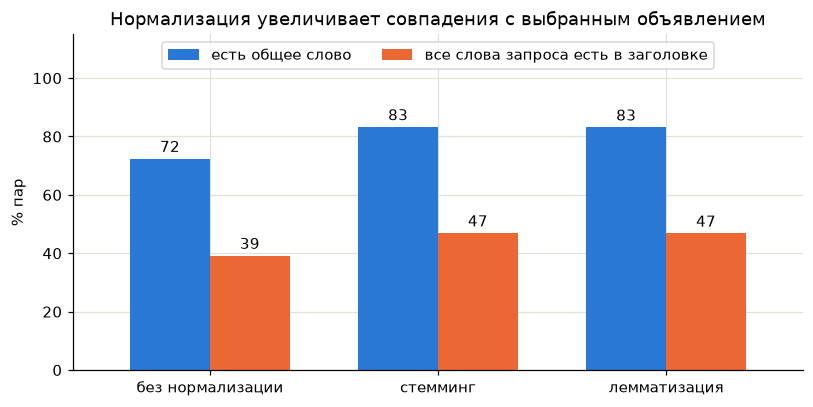

In [28]:
ax = norm_table[['выбранные: есть общее слово, %', 'выбранные: все слова запроса в заголовке, %']].plot.bar(
    color=[BLUE, ORANGE], rot=0, width=0.7, figsize=(7.5, 3.8))
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2)
ax.set_ylim(0, 115); ax.set_ylabel('% пар')
ax.set_title('Нормализация увеличивает совпадения с выбранным объявлением')
ax.legend(['есть общее слово', 'все слова запроса есть в заголовке'], loc='upper center', ncol=2)
plt.tight_layout(); plt.show()

Выводы части 3:
* нормализация сильно помогает: без неё общее слово с заголовком выбранного объявления есть у 72% пар,
  с ней — у 83% (+11 п.п.). При этом у случайных объявлений совпадений почти не прибавилось (3.3% → 3.7%), то есть
  нормализация находит именно нужные совпадения, а не шум;
* стемминг и лемматизация на этой проверке дают одинаковый результат (83.3% и 83.2%). Лемматизация точнее на отдельных
  словах, но такие слова встречаются редко.

Окончательно выберем способ по метрике Recall@50 в следующей части, где построим поиск по словам — алгоритм BM25.

# Часть 4. Поиск по словам: BM25

BM25 — классическая формула оценки "насколько документ подходит к запросу" по совпадающим словам. Три идеи:
* редкие слова важнее частых: совпадение по "дрова" значит много, по "услуги" — почти ничего (вес IDF);
* повтор слова в документе помогает, но с насыщением: 20 повторов ненамного лучше пяти (параметр k1 = 1.2);
* совпадение в коротком тексте весит больше, чем в длинном (параметр b = 0.75).

Скор документа — сумма весов слов запроса, которые в нём встретились. Считаем BM25 отдельно по заголовку,
параметрам и описанию объявления и складываем с весами.

In [29]:
import scipy.sparse as sp

class BM25:
    def __init__(self, docs, k1=1.2, b=0.75):
        '''docs — список документов, каждый документ — список нормализованных слов'''
        self.vocab = {}
        indptr, indices = [0], []
        for doc in docs:
            indices.extend(self.vocab.setdefault(w, len(self.vocab)) for w in doc)
            indptr.append(len(indices))
        tf = sp.csr_matrix((np.ones(len(indices), np.float32), indices, indptr), shape=(len(docs), len(self.vocab)))
        tf.sum_duplicates()                                   # сколько раз слово встречается в документе
        doc_len = np.asarray(tf.sum(axis=1)).ravel()
        df = np.bincount(tf.indices, minlength=len(self.vocab))   # в скольких документах есть слово
        idf = np.log(1 + (len(docs) - df + 0.5) / (df + 0.5)).astype(np.float32)
        tf = tf.tocoo()
        length_norm = k1 * (1 - b + b * doc_len[tf.row] / doc_len.mean())
        weights = idf[tf.col] * tf.data * (k1 + 1) / (tf.data + length_norm)
        self.matrix = sp.csr_matrix((weights.astype(np.float32), (tf.row, tf.col)), shape=tf.shape)

    def scores(self, queries):
        '''queries — список запросов (списков слов) -> матрица скоров "запрос × документ"'''
        indptr, indices = [0], []
        for q in queries:
            indices.extend(sorted({self.vocab[w] for w in q if w in self.vocab}))
            indptr.append(len(indices))
        qm = sp.csr_matrix((np.ones(len(indices), np.float32), indices, indptr), shape=(len(queries), len(self.vocab)))
        return np.asarray((self.matrix @ qm.T).T.todense())

Строим индексы по трём полям объявления для трёх способов нормализации (займёт несколько минут: в корпусе ~200 тысяч
объявлений, описания длинные).

In [30]:
FIELDS = {'title': 'item_title_raw', 'params': 'item_infm_params_text', 'desc': 'item_description_raw'}
indexes = {}
for method in ['none', 'stem', 'lemma']:
    for field, col in FIELDS.items():
        indexes[method, field] = BM25([normalize(t, method) for t in corpus_val[col].fillna('')])
print('индексов:', len(indexes))

индексов: 9


In [31]:
def bm25_search(method, weights, searches, k=50, batch=200):
    '''weights — {поле: вес}; возвращает {query_id: топ-k item_id}'''
    ids = corpus_val.item_id.values
    result = {}
    for start in range(0, len(searches), batch):
        part = searches.iloc[start:start + batch]
        q = [normalize(t, method) for t in part.search_query]
        score = sum(w * indexes[method, field].scores(q) for field, w in weights.items())
        top = np.argpartition(-score, k, axis=1)[:, :k]
        for qid, row, s in zip(part.query_id, top, score):
            result[qid] = list(ids[row[np.argsort(-s[row])]])
    return result

ALL_FIELDS = {'title': 1, 'params': 1, 'desc': 0.5}      # описание длинное и "шумное" — вес меньше
configs = {
    'стемминг, только заголовок': ('stem', {'title': 1}),
    'стемминг, заголовок + параметры': ('stem', {'title': 1, 'params': 1}),
    'стемминг, все поля': ('stem', ALL_FIELDS),
    'без нормализации, все поля': ('none', ALL_FIELDS),
    'лемматизация, все поля': ('lemma', ALL_FIELDS),
}
bm25_results = {name: bm25_search(m, w, val) for name, (m, w) in configs.items()}
pd.Series({name: recall_at_k(r, correct_val) for name, r in bm25_results.items()}, name='Recall@50').round(4).to_frame()

,Recall@50
"стемминг, только заголовок",0.3209
"стемминг, заголовок + параметры",0.2824
"стемминг, все поля",0.3660
"без нормализации, все поля",0.3144
"лемматизация, все поля",0.3681


Выводы:
* нормализация нужна: без неё 31.4%, со стеммингом 36.6% (+5 п.п.);
* стемминг и лемматизация почти равны: 36.6% и 36.8%. Разница 0.2 п.п. — это примерно 6 запросов из 3 000.
  Оставляем стемминг: он проще и быстрее, и на нём построено итоговое решение;
* лучше всего работают все поля вместе. Параметры без описания даже ухудшают поиск: в них много общих слов
  (вид услуги, адрес), которые есть у тысяч объявлений, а описание добавляет конкретики;
* но даже лучший вариант находит правильное объявление только в 37% случаев.

Почему так мало? Посмотрим, откуда найденные объявления:

In [32]:
loc = dict(zip(corpus_val.item_id, corpus_val.item_location_id))
best = bm25_results['стемминг, все поля']
same_loc = np.mean([np.mean([loc[i] == l for i in best[q]]) for q, l in zip(val.query_id, val.search_location_id)])
print(f'доля найденных объявлений из той же локации, что и поиск: {same_loc:.1%}')

доля найденных объявлений из той же локации, что и поиск: 4.3%


Только 4% найденных объявлений находятся в той же локации, что и поиск. BM25 честно находит объявления
с подходящими словами, но по всей стране: "баня на дровах" есть в каждом городе. А из части 1 мы знаем, что
пользователь выбирает объявление из своей локации в 83% случаев.

Следующий шаг — добавить к поиску по словам локацию и фильтр "Вид услуги".

In [33]:
# дальше нужен только вариант со стеммингом — остальные индексы удаляем, чтобы освободить память
for key in [k for k in indexes if k[0] != 'stem']:
    del indexes[key]
gc.collect();

# Часть 5. Добавляем локацию и фильтры — бейзлайн

Из части 1: пользователь выбирает объявление из своей локации в 83% случаев. Но часть поисков сделана в "регионе"
(например, "Москва и область"): объявлений с такой локацией нет вообще, выбор происходит в городах региона.
Поэтому вместо "та же локация" используем окрестность поиска:
* та же локация;
* локации, куда из этой локации выбирают хотя бы в 1% случаев (по fit) — так "регион" связывается со своими городами;
* всё в радиусе 30 км от центра локации (соседние города и районы).

Фильтры добавляем как бонус к скору BM25: +1000 за окрестность, +500 за совпавший "Вид услуги", +100 за подходящую
категорию. BM25 обычно даёт 5–30, поэтому сначала идут объявления, прошедшие фильтры, а среди них порядок задают слова.
Если таких меньше 50, места добирают остальные. Такие фильтры называют мягкими.

In [34]:
def haversine(lat1, lon1, lat2, lon2):
    '''расстояние между точками на Земле, км'''
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

coords = ['item_location_id', 'item_latitude', 'item_longitude']
loc_center = pd.concat([fit[coords], corpus_val[coords]]).groupby('item_location_id').median()   # центр локации
search_center = fit.groupby('search_location_id')[coords[1:]].median()   # центр "региона" — по выбранным из него объявлениям
share = fit.groupby('search_location_id').item_location_id.value_counts(normalize=True)
linked_locs = share[share >= 0.01].reset_index().groupby('search_location_id').item_location_id.apply(set).to_dict()

item_loc = corpus_val.item_location_id.values
item_lat, item_lon = corpus_val.item_latitude.values, corpus_val.item_longitude.values

def neighborhood(L, radius_km=30):
    '''маска объявлений корпуса, попадающих в окрестность локации поиска L'''
    mask = np.isin(item_loc, list(linked_locs.get(L, set()) | {L}))
    if L in loc_center.index:
        center = loc_center.loc[L]
    elif L in search_center.index:
        center = search_center.loc[L]
    else:
        return mask
    return mask | (haversine(center.item_latitude, center.item_longitude, item_lat, item_lon) <= radius_km)

"Вид услуги" надёжнее искать по списку из 26 известных значений, чем простым правилом из части 1: в фильтре
после вида услуги может идти другой фильтр, и простое правило захватило бы лишнее.

In [35]:
VIDS = ['Автосервис, аренда', 'Красота, здоровье', 'Ремонт и отделка', 'Обучение, курсы', 'Строительство',
        'Сад, благоустройство', 'Ремонт и обслуживание техники', 'Праздники, мероприятия', 'Оборудование, производство',
        'Деловые услуги', 'Грузоперевозки', 'Вывоз мусора и вторсырья', 'Фото- и видеосъёмка', 'Пассажирские перевозки',
        'Другое', 'Уход за животными', 'Монтаж и установка техники', 'Компьютерная помощь', 'Доставка еды и продуктов',
        'Бытовые услуги', 'Услуги эвакуатора', 'Уборка', 'Искусство', 'Грузчики, складские услуги', 'Няни, сиделки',
        'Охрана, безопасность']
vid_re = re.compile('Вид услуги (' + '|'.join(re.escape(v) for v in sorted(VIDS, key=len, reverse=True)) + ')')

def get_vid(text):
    m = vid_re.search(text or '')
    return m.group(1) if m else ''

item_vid = np.array([get_vid(t) for t in corpus_val.item_infm_params_text.fillna('')])
item_cat114 = corpus_val.item_category_id.values == 114

def filters(search):
    '''для всех объявлений корпуса: та же локация / окрестность / "Вид услуги" подходит / категория подходит'''
    same = item_loc == search.search_location_id
    near = neighborhood(search.search_location_id)
    vid = get_vid(search.search_infm_params_text)
    vid_ok = (item_vid == vid) if vid else np.ones(len(item_vid), bool)
    cat_ok = item_cat114 if search.search_category == 114 else np.ones(len(item_vid), bool)
    return same, near, vid_ok, cat_ok

Считаем по шагам, что даёт каждое добавление. Для каждого варианта сохраняем топ-500 — пригодится в следующей части.

In [36]:
ids = corpus_val.item_id.values
ladder = {'BM25': {}, '+ та же локация': {}, '+ окрестность (регионы, 30 км)': {}, '+ "Вид услуги" и категория': {}}
for start in range(0, len(val), 200):
    part = val.iloc[start:start + 200]
    S = sum(w * indexes['stem', f].scores([normalize(t, 'stem') for t in part.search_query]) for f, w in ALL_FIELDS.items())
    for j, s in enumerate(part.itertuples()):
        same, near, vid_ok, cat_ok = filters(s)
        variants = [S[j], S[j] + 1000 * same, S[j] + 1000 * near, S[j] + 1000 * near + 500 * vid_ok + 100 * cat_ok]
        for name, score in zip(ladder, variants):
            top = np.argpartition(-score, 500)[:500]
            ladder[name][s.query_id] = list(ids[top[np.argsort(-score[top])]])

pd.Series({name: recall_at_k(r, correct_val) for name, r in ladder.items()}, name='Recall@50').round(4).to_frame()

,Recall@50
BM25,0.3654
+ та же локация,0.7616
"+ окрестность (регионы, 30 км)",0.7894
"+ ""Вид услуги"" и категория",0.8225


Выводы части 5:
* локация — самый большой шаг: 37% → 76%, результат вырос вдвое;
* окрестность (регионы и соседние города) добавляет ещё 3 п.п. (79%), фильтры "Вид услуги" и категория — ещё 3 п.п.;
* итог — бейзлайн 82% на валидации. Этот же алгоритм, посчитанный со статистикой по всему train на корпусе бенчмарка,
  был нашей первой отправкой: 0.770 на лидерборде. Валидация оказалась оптимистичнее лидерборда — к этому вернёмся в конце.

Следующий вопрос: что мешает подняться выше — алгоритм не находит нужное объявление или находит, но ставит слишком низко?

# Часть 6. Развилка: искать лучше или сортировать лучше

Посмотрим, как меняется полнота бейзлайна, если брать не 50 кандидатов, а больше.

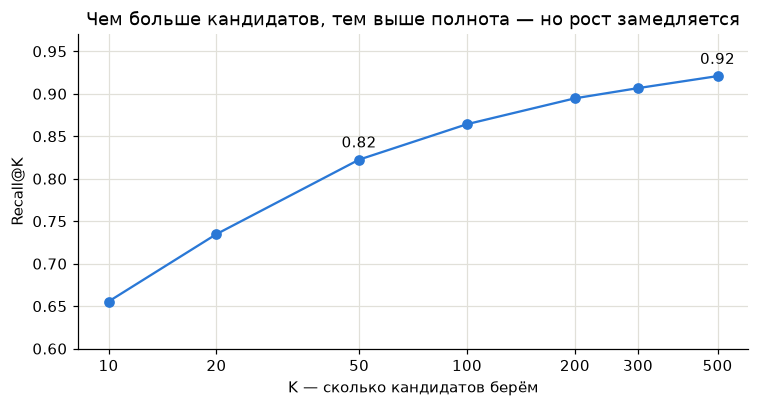

,10,20,50,100,200,300,500
Recall@K,0.655,0.735,0.822,0.864,0.895,0.907,0.921


In [37]:
baseline = ladder['+ "Вид услуги" и категория']
Ks = [10, 20, 50, 100, 200, 300, 500]
curve = pd.Series({k: recall_at_k(baseline, correct_val, k) for k in Ks})

ax = curve.plot(marker='o', color=BLUE, figsize=(7, 3.8), logx=True)
ax.set_xticks(Ks); ax.set_xticklabels(Ks); ax.minorticks_off(); ax.set_ylim(0.6, 0.97)
for k in [50, 500]:
    ax.annotate(f'{curve[k]:.2f}', (k, curve[k]), textcoords='offset points', xytext=(0, 8), ha='center')
ax.set_xlabel('K — сколько кандидатов берём'); ax.set_ylabel('Recall@K')
ax.set_title('Чем больше кандидатов, тем выше полнота — но рост замедляется')
plt.tight_layout(); plt.show()
curve.round(3).rename('Recall@K').to_frame().T

Что видно:
* в топ-50 попадает 82% правильных объявлений, а в топ-500 — уже 92%. Значит, ещё 10% правильных объявлений
  алгоритм находит, но ставит на места с 51-го по 500-е. Проблема не в том, что не можем найти, а в порядке;
* 8% не находятся даже в топ-500 — BM25 их не видит (в части 1 мы видели пары запрос–объявление без общих слов).

Отсюда стандартная для поиска двухэтапная схема:

```
запрос → этап 1: отбор кандидатов → ~500 объявлений → этап 2: ранжирование → 50 объявлений
         (быстро, цель — ничего не упустить)          (медленнее, цель — точный порядок)
```

Почему так, а не одна "умная" модель сразу:
* качество: разницу между 82% и 92% можно отыграть на втором этапе, если точнее упорядочить кандидатов;
* время: точная модель на десятках признаков для всего корпуса — это 2 452 запроса × 189 тысяч объявлений ≈
  460 млн пар. Для 500 кандидатов — 1.2 млн пар, это считается за минуты;
* потолок: второй этап не вернёт объявление, которого нет среди кандидатов. Поэтому полнота первого этапа —
  максимум, которого может достичь всё решение.

Сколько брать кандидатов: кривая выполаживается — от 300 до 500 прибавка уже около 1.5 п.п., а каждый лишний
кандидат замедляет второй этап. Разумный размер — несколько сотен.

План дальше:
* часть 7 — улучшаем первый этап: добавляем источники кандидатов, которые находят то, что не видит BM25;
* часть 8 — второй этап: модель, которая выбирает 50 лучших из кандидатов.

# Часть 7. Первый этап: пул кандидатов из нескольких источников

Цель первого этапа — полнота: правильное объявление должно попасть в пул. BM25 не видит объявления без общих слов
с запросом. Добавим источники, которые ищут по-другому:
1. эмбеддинги — поиск по смыслу;
2. классификатор "запрос → подкатегория" — объявления вероятной подкатегории, популярные выше;
3. "память" — объявления, которые уже выбирали по такому же тексту запроса в train;
4. BM25 без учёта локации — для удалённых услуг (онлайн-репетитор, перевозки в другой город).

## 13. Эмбеддинги: поиск по смыслу

Нейросеть-энкодер превращает текст в вектор из 312 чисел так, чтобы тексты с похожим смыслом получали близкие
векторы. Близость векторов измеряем косинусом. Берём небольшую русскую модель `sergeyzh/rubert-mini-frida`
(32 млн параметров) — она работает на обычном процессоре. Кодируем заголовки объявлений и тексты запросов.

Готовая модель не знает специфики Авито, поэтому дообучаем её на парах "запрос → заголовок выбранного объявления"
из fit. Модель учится делать вектор запроса ближе к "своему" объявлению, чем к объявлениям других пар в той же
пачке (контрастивное обучение, лосс InfoNCE). Одна эпоха на процессоре занимает около 30 минут, поэтому
результат сохраняется в `cache/` и при повторном запуске загружается.

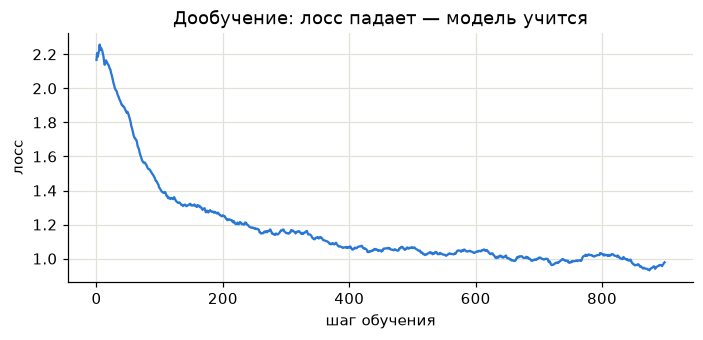

In [38]:
import os, json, collections
import torch
from sentence_transformers import SentenceTransformer

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'    # видеокарта, если есть
torch.set_num_threads(min(16, os.cpu_count())); torch.manual_seed(42)
CACHE = 'cache'
BASE_MODEL, FT_PATH = 'sergeyzh/rubert-mini-frida', f'{CACHE}/rubert-mini-frida-ft'

def finetune(steps=900, batch_size=128, lr=1e-4, scale=20.0):
    rng = np.random.RandomState(42); torch.manual_seed(42)
    pairs = fit[['search_query', 'item_title_raw']].drop_duplicates()
    pairs = pairs.sample(frac=1, random_state=42).groupby('search_query').head(3).reset_index(drop=True)  # ≤ 3 пар на текст
    qs, ds = pairs.search_query.values, pairs.item_title_raw.values
    batches, cur, seen_q, seen_d = [], [], set(), set()
    for i in rng.permutation(len(pairs)):          # в одном батче не повторяются ни запросы, ни заголовки
        if qs[i] in seen_q or ds[i] in seen_d:
            continue
        cur.append(i); seen_q.add(qs[i]); seen_d.add(ds[i])
        if len(cur) == batch_size:
            batches.append(cur); cur, seen_q, seen_d = [], set(), set()
    model = SentenceTransformer(BASE_MODEL, device=DEVICE); model.max_seq_length = 32
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: (s + 1) / 100 if s < 100 else max(0.0, (steps - s) / (steps - 100)))
    prep = model.preprocess if hasattr(model, 'preprocess') else model.tokenize
    embed = lambda texts: torch.nn.functional.normalize(
        model({k: v.to(DEVICE) for k, v in prep(texts).items()})['sentence_embedding'], dim=-1)
    model.train(); history = []
    for step in range(steps):
        b = batches[step % len(batches)]
        sim = embed(['search_query: ' + x for x in qs[b]]) @ embed(['search_document: ' + x for x in ds[b]]).T * scale
        labels = torch.arange(len(b), device=DEVICE)        # "правильная" пара для i-го запроса — i-й заголовок
        loss = (torch.nn.functional.cross_entropy(sim, labels) + torch.nn.functional.cross_entropy(sim.T, labels)) / 2
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        history.append(loss.item())
    model.eval(); model.save(FT_PATH)
    json.dump(history, open(f'{FT_PATH}/loss_history.json', 'w'))

if not os.path.exists(f'{FT_PATH}/loss_history.json'):
    finetune()
history = pd.Series(json.load(open(f'{FT_PATH}/loss_history.json')))
ax = history.rolling(50, min_periods=1).mean().plot(color=BLUE, figsize=(6.5, 3.2))
ax.set_xlabel('шаг обучения'); ax.set_ylabel('лосс'); ax.set_title('Дообучение: лосс падает — модель учится')
plt.tight_layout(); plt.show()

In [39]:
def encode(model, texts, prompt_name):
    model.max_seq_length = 32
    return model.encode(list(texts), prompt_name=prompt_name, batch_size=128, normalize_embeddings=True,
                        convert_to_numpy=True, show_progress_bar=False).astype(np.float32)

def get_embeddings(model_path, tag):
    """векторы заголовков корпуса, отложенных запросов и тестовых запросов (с кэшем на диске)"""
    path = f'{CACHE}/emb_{tag}.npz'
    if not os.path.exists(path):
        m = SentenceTransformer(model_path, device=DEVICE)
        np.savez(path, C=encode(m, corpus_val.item_title_raw.fillna(''), 'passage').astype(np.float16),
                 H=encode(m, holdout.search_query, 'query').astype(np.float16),
                 B=encode(m, queries.search_query, 'query').astype(np.float16))
    z = np.load(path)
    return z['C'].astype(np.float32), z['H'].astype(np.float32), z['B'].astype(np.float32)

emb_pre = get_embeddings(BASE_MODEL, 'pretrained')   # готовая модель
emb_ft = get_embeddings(FT_PATH, 'finetuned')        # дообученная модель
print('устройство для нейросети:', DEVICE)
print('векторы корпуса:', emb_ft[0].shape)

устройство для нейросети: cpu
векторы корпуса: (197947, 312)


У модели в настройках по умолчанию стоит "режим классификации", поэтому явно указываем режимы `query` (для запросов)
и `passage` (для объявлений) — так модель используется по назначению.

## 14. Классификатор "запрос → подкатегория"

У каждого объявления есть подкатегория (`item_microcat_id`, в train их 212): "маникюр", "грузоперевозки" и т.д.
Обучаем простой классификатор: по тексту запроса предсказать подкатегорию выбранного объявления.
Признаки — TF-IDF по словам (со стеммингом) и по кусочкам слов из 3–5 букв (устойчиво к опечаткам),
модель — логистическая регрессия. Учим на уникальных парах "текст — подкатегория", чтобы частые запросы
не доминировали.

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier

def word_ngrams(text):
    t = normalize(text, 'stem')
    return t + [a + '_' + b for a, b in zip(t, t[1:])]

def train_microcat(stats):
    g = stats.groupby(['search_query', 'item_microcat_id']).size().rename('n').reset_index()
    vw = TfidfVectorizer(analyzer=word_ngrams, min_df=2, sublinear_tf=True)
    vc = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, sublinear_tf=True, max_features=300000,
                         preprocessor=lambda s: s.lower().replace('ё', 'е'))
    X = sp.hstack([vw.fit_transform(g.search_query), vc.fit_transform(g.search_query)]).tocsr()
    clf = SGDClassifier(loss='log_loss', alpha=1e-6, max_iter=15, tol=None, n_jobs=-1, random_state=0)
    clf.fit(X, g.item_microcat_id.values, sample_weight=np.sqrt(g.n.values))
    return {'vw': vw, 'vc': vc, 'clf': clf, 'cls_idx': {c: i for i, c in enumerate(clf.classes_)}}

def microcat_proba(mc, texts):
    X = sp.hstack([mc['vw'].transform(texts), mc['vc'].transform(texts)]).tocsr()
    return mc['clf'].predict_proba(X).astype(np.float32)

mc_fit = train_microcat(fit)
P_val = microcat_proba(mc_fit, val.search_query.tolist())
true_mc = holdout_rows.drop_duplicates('query_id').set_index('query_id').item_microcat_id.reindex(val.query_id).values
rank_true = np.array([(p > p[mc_fit['cls_idx'][m]]).sum() if m in mc_fit['cls_idx'] else 999 for p, m in zip(P_val, true_mc)])
print(f'угадана подкатегория: с 1-й попытки {np.mean(rank_true == 0):.0%}, в топ-3 {np.mean(rank_true < 3):.0%}, '
      f'в топ-10 {np.mean(rank_true < 10):.0%}')

угадана подкатегория: с 1-й попытки 67%, в топ-3 84%, в топ-10 93%


## 15. Собираем пул и считаем его полноту

Для каждого запроса берём:
* BM25 с фильтрами (как в бейзлайне) — топ-300;
* эмбеддинги с теми же фильтрами — топ-200;
* классификатор: вероятность подкатегории × популярность (число отзывов) с фильтрами — топ-100;
* BM25 без локации — топ-30;
* "память": объявления, выбранные в train по такому же тексту, — до 50 (сначала из окрестности).

Пул — объединение всех источников. Для окрестности теперь нужны не только маска, но и сами числа
(доля выборов и расстояние) — они понадобятся ранкеру, поэтому считаем их отдельной функцией.

In [41]:
def build_context(stats, corpus, mc):
    """всё, что нужно для поиска по корпусу corpus, со статистикой по stats и классификатором подкатегорий mc"""
    coords = ['item_location_id', 'item_latitude', 'item_longitude']
    shares = stats.groupby('search_location_id').item_location_id.value_counts(normalize=True)
    pos = {x: i for i, x in enumerate(corpus.item_id.values)}
    known = stats[stats.item_id.isin(pos)]
    uloc, loc_idx = np.unique(corpus.item_location_id.values, return_inverse=True)
    return {
        'N': len(corpus), 'ids': corpus.item_id.values, 'item_loc': corpus.item_location_id.values,
        'lat': corpus.item_latitude.values, 'lon': corpus.item_longitude.values, 'uloc': uloc, 'loc_idx': loc_idx,
        'center': pd.concat([stats[coords], corpus[coords]]).groupby('item_location_id')[coords[1:]].median(),
        'region_center': stats.groupby('search_location_id')[coords[1:]].median(),
        'shares': {L: s.droplevel(0).to_dict() for L, s in shares.groupby(level=0)},
        'item_vid': np.array([get_vid(t) for t in corpus.item_infm_params_text.fillna('')]),
        'cat114': corpus.item_category_id.values == 114,
        'rev': np.log1p(corpus.item_rating_reviews_count.fillna(0).values).astype(np.float32),
        'memory': known.groupby('search_query').item_id.apply(lambda s: [pos[x] for x in s]).to_dict(),
        'doc_mc_idx': np.array([mc['cls_idx'].get(m, -1) for m in corpus.item_microcat_id.values]),
    }

def location_features(ctx, L):
    """та же локация / доля выборов в локации объявления при поиске из L / расстояние до центра L (км)"""
    same = ctx['item_loc'] == L
    v = np.zeros(len(ctx['uloc']), np.float32)
    for l, p in ctx['shares'].get(L, {}).items():
        i = np.searchsorted(ctx['uloc'], l)
        if i < len(ctx['uloc']) and ctx['uloc'][i] == l:
            v[i] = p
    p_assoc = v[ctx['loc_idx']]
    if L in ctx['center'].index:
        c = ctx['center'].loc[L]
    elif L in ctx['region_center'].index:
        c = ctx['region_center'].loc[L]
    else:
        return same, p_assoc, np.full(ctx['N'], 5000, np.float32)
    return same, p_assoc, haversine(c.item_latitude, c.item_longitude, ctx['lat'], ctx['lon']).astype(np.float32)

def top(score, k):
    i = np.argpartition(-score, k)[:k]
    return i[np.argsort(-score[i])]

def get_sources(s, S_row, E_row, P_row, ctx):
    """источники кандидатов для одного поиска s: {источник: позиции объявлений по убыванию скора}"""
    same, p_assoc, dist = location_features(ctx, s.search_location_id)
    near = same | (p_assoc >= 0.01) | (dist <= 30)
    vid = get_vid(s.search_infm_params_text)
    vid_ok = (ctx['item_vid'] == vid) if vid else np.ones(ctx['N'], bool)
    cat_ok = ctx['cat114'] if s.search_category == 114 else np.ones(ctx['N'], bool)
    F = 1000 * near + 500 * vid_ok + 100 * cat_ok                       # мягкие фильтры, как в бейзлайне
    pm = np.where(ctx['doc_mc_idx'] >= 0, P_row[ctx['doc_mc_idx']], 0).astype(np.float32)   # P(подкатегория объявления | запрос)
    src = {'bm': top(S_row + F, 300), 'dense': top(E_row + F, 200),
           'mc': top(pm * (1 + 0.1 * ctx['rev']) + F, 100), 'glob': top(S_row + 100 * cat_ok, 30)}
    mem = ctx['memory'].get(s.search_query, [])
    if mem:
        cnt = collections.Counter(mem)
        src['mem'] = np.array(sorted(cnt, key=lambda i: (-int(near[i]), -cnt[i], dist[i]))[:50])
    info = dict(same=same, p_assoc=p_assoc, dist=dist, near=near, vid=vid, vid_ok=vid_ok, cat_ok=cat_ok, pm=pm, F=F)
    return src, info

In [42]:
ctx_val = build_context(fit, corpus_val, mc_fit)
val_pos = np.where(holdout.part.values == 'val')[0]          # строки отложенных поисков, относящиеся к val
C_ft, H_ft = emb_ft[0], emb_ft[1][val_pos]
C_pre, H_pre = emb_pre[0], emb_pre[1][val_pos]

sources, dense_pre = {}, {}
for start in range(0, len(val), 200):
    part = val.iloc[start:start + 200]
    S = sum(w * indexes['stem', f].scores([normalize(t, 'stem') for t in part.search_query]) for f, w in ALL_FIELDS.items())
    E, E_pre = H_ft[start:start + 200] @ C_ft.T, H_pre[start:start + 200] @ C_pre.T
    for j, s in enumerate(part.itertuples()):
        sources[s.query_id], info = get_sources(s, S[j], E[j], P_val[start + j], ctx_val)
        dense_pre[s.query_id] = top(E_pre[j] + info['F'], 200)

def as_ids(positions):
    return list(ctx_val['ids'][positions])

pd.Series({
    'BM25 + фильтры (бейзлайн)': recall_at_k({q: as_ids(v['bm']) for q, v in sources.items()}, correct_val),
    'эмбеддинги готовой модели + фильтры': recall_at_k({q: as_ids(v) for q, v in dense_pre.items()}, correct_val),
    'эмбеддинги дообученной модели + фильтры': recall_at_k({q: as_ids(v['dense']) for q, v in sources.items()}, correct_val),
}, name='Recall@50').round(4).to_frame()

,Recall@50
BM25 + фильтры (бейзлайн),0.8222
эмбеддинги готовой модели + фильтры,0.7613
эмбеддинги дообученной модели + фильтры,0.8340


Готовая модель ищет хуже BM25 (76% против 82%): короткие запросы с точными словами — сильная сторона поиска по словам.
После дообучения на наших данных эмбеддинги обгоняют BM25 (83.4%): модель выучила, какие объявления реально выбирают
по таким запросам, включая синонимы и перефразы.

Теперь полнота пула: как она растёт, когда добавляем источники по одному.

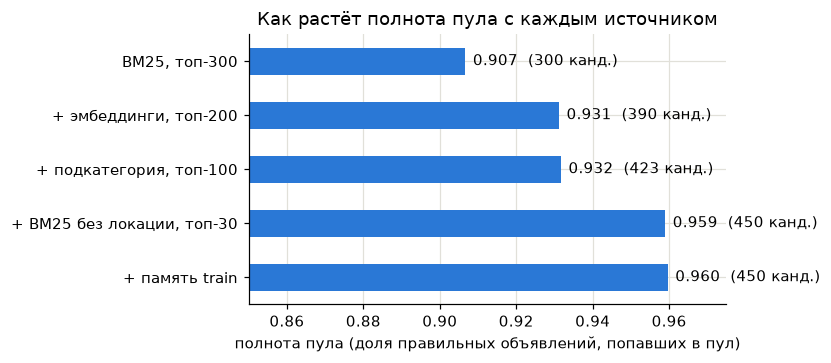

,полнота пула,кандидатов в среднем
шаг,,
"BM25, топ-300",0.907,300.000
"+ эмбеддинги, топ-200",0.931,390.311
"+ подкатегория, топ-100",0.932,422.970
"+ BM25 без локации, топ-30",0.959,449.793
+ память train,0.960,450.058


In [43]:
steps = [('BM25, топ-300', ['bm']), ('+ эмбеддинги, топ-200', ['bm', 'dense']), ('+ подкатегория, топ-100', ['bm', 'dense', 'mc']),
         ('+ BM25 без локации, топ-30', ['bm', 'dense', 'mc', 'glob']), ('+ память train', ['bm', 'dense', 'mc', 'glob', 'mem'])]
rows = []
for name, used in steps:
    pools = {q: set(as_ids(np.concatenate([v[k] for k in used if k in v]))) for q, v in sources.items()}
    rows.append({'шаг': name, 'полнота пула': np.mean([len(pools[q] & correct_val[q]) / len(correct_val[q]) for q in correct_val]),
                 'кандидатов в среднем': np.mean([len(p) for p in pools.values()])})
pool_table = pd.DataFrame(rows).set_index('шаг')

ax = pool_table['полнота пула'].plot.barh(color=BLUE, figsize=(7.5, 3.4), xlim=(0.85, 0.975))
ax.invert_yaxis()
for i, (r, n) in enumerate(zip(pool_table['полнота пула'], pool_table['кандидатов в среднем'])):
    ax.text(r + 0.002, i, f'{r:.3f}  ({n:.0f} канд.)', va='center')
ax.set_xlabel('полнота пула (доля правильных объявлений, попавших в пул)'); ax.set_ylabel('')
ax.set_title('Как растёт полнота пула с каждым источником')
plt.tight_layout(); plt.show()
pool_table.round(3)

Выводы части 7:
* эмбеддинги добавляют к пулу BM25 2.4 п.п. — это объявления, найденные по смыслу, а не по словам;
* больше всего добавляет BM25 без локации: +2.7 п.п. Это удалённые услуги и поиски, где выбрали объявление
  из другого города, — окрестность такие объявления отсекает;
* подкатегория и память добавляют по 0.1 п.п.: почти всё, что они находят, уже нашли другие источники. Оставляем их,
  потому что их оценки пригодятся ранкеру как признаки;
* итог: пул из ~450 кандидатов содержит правильное объявление в 96% случаев (у одного BM25 с топ-300 — 91%).

Задача второго этапа — выбрать из ~450 кандидатов 50 так, чтобы потерять как можно меньше из этих 96%.

# Часть 8. Второй этап: ранкер CatBoost

Для каждого поиска у нас есть пул из ~450 кандидатов. Превращаем задачу в обычную классификацию: одна строка —
пара "поиск — кандидат", метка 1, если пользователь выбрал это объявление, иначе 0. Модель учится предсказывать
вероятность выбора, и мы берём 50 кандидатов с наибольшей вероятностью.

Признаки пары (всё, что мы нашли полезным в предыдущих частях):
* текст: BM25 по каждому полю, BM25 по "истории" объявления (тексты запросов, по которым его выбирали в train),
  косинус эмбеддингов, доля слов запроса в заголовке;
* локация: та же ли локация, доля выборов в локации объявления, расстояние, в окрестности ли;
* фильтры: совпадение "Вида услуги" и "Типа услуги", фильтр по рейтингу;
* подкатегория: вероятность подкатегории объявления по классификатору;
* поведение: сколько раз объявление выбирали по этому тексту и в этой локации, его популярность;
* объявление: отзывы, рейтинг, цена, длина текстов;
* источники: место объявления в каждом источнике кандидатов.

In [44]:
from catboost import CatBoostClassifier, Pool

RATING_FILTER = 'Рейтинг пользователя 4 звезды и выше'

def get_tip(text):
    '''значение "Тип услуги" из фильтра поиска'''
    m = re.search(r'Тип услуги (.+?)(?: Вид услуги|$)', text or '')
    t = m.group(1).strip() if m else ''
    return '' if t.startswith('Вид услуги') else t

def add_ranker_context(ctx, stats, corpus, emb):
    '''дополняет контекст всем, что нужно для признаков ранкера'''
    title = [normalize(t, 'stem') for t in corpus.item_title_raw.fillna('')]
    params = [normalize(t, 'stem') for t in corpus.item_infm_params_text.fillna('')]
    pos = {x: i for i, x in enumerate(corpus.item_id.values)}
    known = stats[stats.item_id.isin(pos)]
    history = collections.defaultdict(list)                  # тексты запросов, по которым выбирали объявление
    for item, text in zip(known.item_id.values, known.search_query.values):
        history[pos[item]].extend(normalize(text, 'stem'))
    pop = known.item_id.map(pos).value_counts().reindex(range(len(corpus)), fill_value=0).values
    c = corpus
    ctx.update({
        'emb': emb, 'history_index': BM25([history.get(i, []) for i in range(len(corpus))]),
        'title_sets': [set(x) for x in title], 'params_sets': [set(x) for x in params],
        'title_params_sets': [set(a) | set(b) for a, b in zip(title, params)],
        'item_params': c.item_infm_params_text.fillna('').values, 'rating': c.item_rating.fillna(0).values,
        'doc_mc': c.item_microcat_id.values, 'text_seen': set(stats.search_query.unique()),
        'mem_t': stats.groupby(['search_query', 'item_id']).size().to_dict(),
        'mem_tl': stats.groupby(['search_query', 'search_location_id', 'item_id']).size().to_dict(),
        'pop_loc': known.groupby(['search_location_id', 'item_id']).size().to_dict(),
        'text_mc': stats.groupby('search_query').item_microcat_id.value_counts(normalize=True).to_dict(),
        'static': pd.DataFrame({
            'it_reviews': np.log1p(c.item_rating_reviews_count.fillna(0).values),
            'it_rating': c.item_rating.fillna(-1).values,
            'it_price': np.log1p(c.item_price.fillna(-1).clip(lower=0).values),
            'it_phone_hidden': c.item_is_phone_hidden.astype(float).values,
            'it_msg_forbidden': c.item_is_message_forbidden.astype(float).values,
            'it_title_len': np.array([len(x) for x in title], np.float32),
            'it_desc_len': np.log1p(c.item_description_raw.fillna('').str.len().values),
            'it_pop': np.log1p(pop),
        }).astype(np.float32),
    })

In [45]:
def build_features(searches, H, P, ctx, idx):
    '''пул кандидатов и признаки пар "поиск — кандидат". H — эмбеддинги запросов, P — вероятности подкатегорий,
    idx — BM25-индексы полей корпуса'''
    out = []
    for start in range(0, len(searches), 200):
        part = searches.iloc[start:start + 200]
        qtok = [normalize(t, 'stem') for t in part.search_query]
        St, Sp, Sd = (idx[f].scores(qtok) for f in ['title', 'params', 'desc'])
        Sh, S = ctx['history_index'].scores(qtok), St + Sp + 0.5 * Sd
        E = H[start:start + 200] @ ctx['emb'].T
        for j, s in enumerate(part.itertuples()):
            src, x = get_sources(s, S[j], E[j], P[start + j], ctx)
            pool = np.unique(np.concatenate(list(src.values())))
            n, near, q = len(pool), x['near'], set(qtok[j])
            f = {'item_pos': pool}
            for name in ['bm', 'dense', 'mc', 'glob', 'mem']:          # место в каждом источнике (9999 — нет в нём)
                rank = np.full(ctx['N'], 9999, np.int32)
                if name in src:
                    rank[src[name]] = np.arange(len(src[name]))
                f['rk_' + name] = rank[pool]
            # текст
            f['bm25_title'], f['bm25_params'], f['bm25_desc'] = St[j][pool], Sp[j][pool], Sd[j][pool]
            f['bm25_hist'], f['bm25_sum'] = Sh[j][pool], S[j][pool]
            f['bm25_rel'] = S[j][pool] / (S[j][near].max() + 1e-6 if near.any() else 1)
            f['cos'] = E[j][pool]
            f['cos_rel'] = E[j][pool] - (E[j][near].max() if near.any() else 0)
            f['cov_title'] = np.array([len(q & ctx['title_sets'][i]) / max(len(q), 1) for i in pool], np.float32)
            f['cov_tp'] = np.array([len(q & ctx['title_params_sets'][i]) / max(len(q), 1) for i in pool], np.float32)
            # локация и фильтры (-1 — у поиска нет такого фильтра)
            f['same_loc'], f['p_assoc'], f['dist'] = x['same'][pool].astype(np.float32), x['p_assoc'][pool], np.log1p(x['dist'][pool])
            f['in_neigh'] = near[pool].astype(np.float32)
            f['vid_match'] = x['vid_ok'][pool].astype(np.float32) if x['vid'] else np.full(n, -1, np.float32)
            tip = get_tip(s.search_infm_params_text)
            f['tip_match'] = (np.array([('Тип услуги ' + tip) in ctx['item_params'][i] for i in pool], np.float32)
                              if tip else np.full(n, -1, np.float32))
            sp_tok = set(normalize(s.search_infm_params_text, 'stem'))
            f['sp_overlap'] = (np.array([len(sp_tok & ctx['params_sets'][i]) / len(sp_tok) for i in pool], np.float32)
                               if sp_tok else np.full(n, -1, np.float32))
            f['rating_ok'] = ((ctx['rating'][pool] >= 4).astype(np.float32) if RATING_FILTER in s.search_infm_params_text
                              else np.full(n, -1, np.float32))
            f['cat_ok'] = x['cat_ok'][pool].astype(np.float32)
            # подкатегория и поведение пользователей в train
            f['p_mc'], f['p_mc_rel'] = x['pm'][pool], x['pm'][pool] / (P[start + j].max() + 1e-6)
            f['text_mc'] = np.array([ctx['text_mc'].get((s.search_query, m), 0.0) for m in ctx['doc_mc'][pool]], np.float32)
            f['text_seen'] = np.full(n, float(s.search_query in ctx['text_seen']), np.float32)
            item_ids = ctx['ids'][pool]
            f['mem_t'] = np.array([ctx['mem_t'].get((s.search_query, i), 0) for i in item_ids], np.float32)
            f['mem_tl'] = np.array([ctx['mem_tl'].get((s.search_query, s.search_location_id, i), 0) for i in item_ids], np.float32)
            f['pop_loc'] = np.log1p(np.array([ctx['pop_loc'].get((s.search_location_id, i), 0) for i in item_ids], np.float32))
            # запрос
            f['q_len'] = np.full(n, len(qtok[j]), np.float32)
            f['q_n_neigh'] = np.full(n, np.log1p(near.sum()), np.float32)
            f['q_is_region'] = np.full(n, float(s.search_location_id not in ctx['center'].index), np.float32)
            f['q_has_vid'] = np.full(n, float(bool(x['vid'])), np.float32)
            df = pd.DataFrame(f)
            df.insert(0, 'query_id', s.query_id)
            out.append(df)
    res = pd.concat(out, ignore_index=True)
    res = pd.concat([res, ctx['static'].iloc[res.item_pos.values].reset_index(drop=True)], axis=1)
    res['item_id'] = ctx['ids'][res.item_pos.values]
    num = res.columns.difference(['query_id', 'item_id', 'item_pos'])
    res[num] = res[num].astype(np.float32)
    return res

Строим пулы и признаки для всех 9 000 отложенных поисков (около 7 минут).

In [46]:
add_ranker_context(ctx_val, fit, corpus_val, emb_ft[0])
idx_val = {f: indexes['stem', f] for f in ['title', 'params', 'desc']}
P_holdout = microcat_proba(mc_fit, holdout.search_query.tolist())

feats_h = build_features(holdout, emb_ft[1], P_holdout, ctx_val, idx_val)
right_pairs = set(zip(holdout_rows.query_id, holdout_rows.item_id))
feats_h['label'] = np.array([(a, b) in right_pairs for a, b in zip(feats_h.query_id, feats_h.item_id)], np.int8)
feats_h = feats_h.merge(holdout[['query_id', 'part']], on='query_id')
print(f'пар "поиск — кандидат": {len(feats_h):,}; кандидатов на поиск: {feats_h.groupby("query_id").size().mean():.0f}')

пар "поиск — кандидат": 4,039,898; кандидатов на поиск: 449


Обучаем CatBoost на 5 000 поисков из `rank`, ещё 1 000 из `rank` — для ранней остановки (когда качество на них
перестаёт расти, обучение останавливается). Поиски, где правильного объявления нет в пуле, в обучение не берём:
учиться на них нечему. Проверяем на 3 000 поисков `val`.

In [47]:
FEATS = [c for c in feats_h.columns if c not in ['query_id', 'item_pos', 'item_id', 'label', 'part']]
rank_ids = holdout[holdout.part == 'rank'].query_id.values
es_ids, trn_ids = set(rank_ids[-1000:]), set(rank_ids[:-1000])
has_pos = feats_h.groupby('query_id').label.transform('max') > 0
d_trn = feats_h[feats_h.query_id.isin(trn_ids) & has_pos].sort_values('query_id')
d_es = feats_h[feats_h.query_id.isin(es_ids) & has_pos].sort_values('query_id')
d_val = feats_h[feats_h.part == 'val']

def train_ranker(data, iterations=2000, early_stopping=True):
    model = CatBoostClassifier(loss_function='Logloss', iterations=iterations, learning_rate=0.1, depth=7, l2_leaf_reg=3,
                               random_seed=0, thread_count=16, verbose=0, early_stopping_rounds=150 if early_stopping else None)
    model.fit(Pool(data[FEATS], data.label), eval_set=Pool(d_es[FEATS], d_es.label) if early_stopping else None)
    return model

def top50_recall(df, score):
    top = df.assign(score=score).sort_values(['query_id', 'score'], ascending=[True, False]).groupby('query_id').head(50)
    return recall_at_k(top.groupby('query_id').item_id.apply(list).to_dict(), correct_val)

ranker = train_ranker(d_trn)
pd.Series({
    'бейзлайн: BM25 + фильтры': recall_at_k({q: as_ids(v['bm']) for q, v in sources.items()}, correct_val),
    'простое правило на пуле (BM25 + косинус + фильтры)': top50_recall(d_val, d_val.bm25_rel + d_val.cos + 10 * d_val.in_neigh
                                                                         + 5 * (d_val.vid_match != 0) + d_val.cat_ok),
    'CatBoost на пуле': top50_recall(d_val, ranker.predict(d_val[FEATS], prediction_type='RawFormulaVal')),
}, name='Recall@50 (val)').round(4).to_frame()

,Recall@50 (val)
бейзлайн: BM25 + фильтры,0.8222
простое правило на пуле (BM25 + косинус + фильтры),0.8642
CatBoost на пуле,0.9244


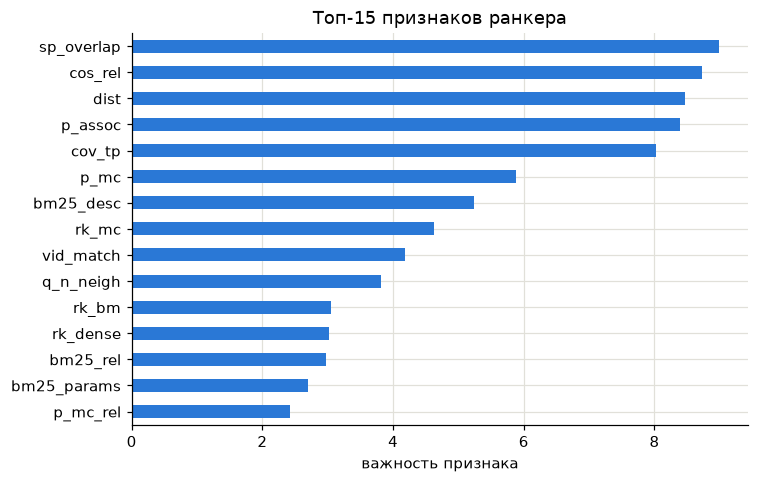

In [48]:
importance = pd.Series(ranker.get_feature_importance(), index=FEATS).sort_values().tail(15)
ax = importance.plot.barh(color=BLUE, figsize=(7, 4.5))
ax.set_xlabel('важность признака'); ax.set_title('Топ-15 признаков ранкера')
plt.tight_layout(); plt.show()

Выводы части 8:
* CatBoost поднимает Recall@50 с 82% (бейзлайн) и 86% (простое правило на том же пуле) до 92.4%. Потолок — полнота
  пула 96%, так что ранкер теряет всего ~3.5 п.п. из доступного;
* самые важные признаки: совпадение фильтров поиска с параметрами объявления (`sp_overlap`), близость по эмбеддингам
  относительно лучшего кандидата (`cos_rel`), расстояние (`dist`), доля выборов в локации объявления (`p_assoc`) и доля
  слов запроса в заголовке и параметрах (`cov_tp`). Это то же, что мы нашли полезным ещё в части 1 — локация, фильтры,
  слова, — плюс смысл из эмбеддингов;
* этот же ранкер, обученный на всех 9 000 отложенных поисков и применённый к тестовым запросам, дал на лидерборде 0.881.

Это и есть итоговая модель. Осталось применить её к тестовым запросам и сохранить ответ.

# Часть 9. Финальное решение и answer.csv

Собираем всё вместе для тестовых запросов:
* статистика (окрестности, память, история запросов, классификатор подкатегорий) теперь считается по всему train;
* корпус — только `benchmark_items`, эмбеддинги — дообученной моделью (посчитаны в части 7);
* ранкер учится на всех 9 000 отложенных поисках (`rank` + `val`); число деревьев — найденное ранней остановкой × 1.2,
  потому что данных стало больше;
* для каждого запроса берём 50 кандидатов с наибольшей оценкой ранкера.

In [49]:
del ctx_val, sources, d_trn, d_es     # больше не нужны — освобождаем память
gc.collect()

mc_full = train_microcat(train)
ctx_bench = build_context(train, items, mc_full)
add_ranker_context(ctx_bench, train, items, emb_ft[0][:len(items)])    # первые строки corpus_val — это items
idx_bench = {f: BM25([normalize(t, 'stem') for t in items[col].fillna('')]) for f, col in FIELDS.items()}
feats_b = build_features(queries, emb_ft[2], microcat_proba(mc_full, queries.search_query.tolist()), ctx_bench, idx_bench)
print(f'кандидатов на запрос: {feats_b.groupby("query_id").size().mean():.0f}')

кандидатов на запрос: 442


In [50]:
final_iterations = int(ranker.get_best_iteration() * 1.2) + 1
d_all = feats_h[feats_h.groupby('query_id').label.transform('max') > 0]
final_ranker = train_ranker(d_all, iterations=final_iterations, early_stopping=False)

feats_b['score'] = final_ranker.predict(feats_b[FEATS], prediction_type='RawFormulaVal')
top = feats_b.sort_values(['query_id', 'score'], ascending=[True, False]).groupby('query_id').head(50)
answer = queries[['query_id']].merge(top.groupby('query_id').item_id.apply(' '.join).rename('answer').reset_index(),
                                     on='query_id')
answer.to_csv('answer.csv', index=False)
print('деревьев в финальном ранкере:', final_iterations, '| answer.csv сохранён')

деревьев в финальном ранкере: 356 | answer.csv сохранён


Проверяем формат по требованиям задачи:

In [51]:
check = pd.read_csv('answer.csv', dtype=str, keep_default_na=False)
lists = check.answer.str.split(' ')
corpus_ids = set(items.item_id)
checks = pd.Series({
    'колонки ровно query_id и answer': list(check.columns) == ['query_id', 'answer'],
    'все запросы, без лишних и повторов': len(check) == len(queries) and set(check.query_id) == set(queries.query_id),
    'в каждой строке 50 разных item_id': bool(lists.apply(lambda x: len(x) == 50 and len(set(x)) == 50).all()),
    'item_id — 16 символов 0-9a-f и есть в корпусе': bool(all(re.fullmatch('[0-9a-f]{16}', x) and x in corpus_ids
                                                              for l in lists for x in l)),
}, name='ok')
assert checks.all()
checks.to_frame()

,ok
колонки ровно query_id и answer,True
"все запросы, без лишних и повторов",True
в каждой строке 50 разных item_id,True
item_id — 16 символов 0-9a-f и есть в корпусе,True


## Итоги

| Шаг | Recall@50, валидация | Recall@50, лидерборд |
|---|---|---|
| BM25 + окрестность локации + фильтры (бейзлайн) | 0.822 | 0.770 |
| Пул из 5 источников + ранкер CatBoost (итоговое решение) | 0.924 | 0.881 |

Что сработало:
* локация — самый сильный сигнал: вместе с окрестностью (регионы, 30 км) она поднимает поиск по словам с 37% до 79%;
* мягкие фильтры "Вид услуги" и категория (+3 п.п.), нормализация слов стеммингом (+5 п.п. к BM25);
* дообученные эмбеддинги: поиск по смыслу находит то, что не видит BM25;
* двухэтапная схема: полный пул (96% правильных объявлений) и ранкер CatBoost, который выбирает из него 50.

In [52]:
print(f'Полное время выполнения ноутбука: {(time.time() - T_START) / 60:.0f} мин')

Полное время выполнения ноутбука: 29 мин
